# Exploratory Data Analysis of the LINK DANDI Dataset (Monkey N)

This notebook performs a structured exploratory data analysis of the NWB-formatted intracortical recordings for **sub-Monkey-N**.

## Objectives
1. Validate the Kaggle-mounted dataset path.
2. Build a session-level inventory from all NWB files.
3. Extract NWB metadata relevant to decoding and longitudinal analysis.
4. Inspect trials, units, electrodes, acquisition streams, and processing modules.
5. Generate publication-style figures for the manuscript.

## Dataset path
`/kaggle/input/datasets/katakuricharlotte/dandi-dataset/001201/sub-Monkey-N`

## Example session file
`/kaggle/input/datasets/katakuricharlotte/dandi-dataset/001201/sub-Monkey-N/sub-Monkey-N_ses-20200127_ecephys.nwb`

In [3]:
!pip install pynwb h5py

In [4]:
import os
import re
import json
import math
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    from pynwb import NWBHDF5IO
except Exception as e:
    raise ImportError(
        "pynwb is required for this notebook. Please install/enable it in Kaggle."
    ) from e

try:
    import yaml
except Exception:
    yaml = None

In [5]:
# -------------------------------
# GLOBAL PAPER-STYLE SETTINGS
# -------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,

    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "axes.linewidth": 1.2,

    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "legend.fontsize": 11,
    "legend.frameon": True,
    "legend.edgecolor": "0.4",

    "grid.linestyle": ":",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.85,
})

def paper_axes(ax):
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle=":", linewidth=0.8)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.7)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    ax.tick_params(which="both", direction="in", top=True, right=True)

np.random.seed(7)

## Paths and output folders

All figures, tables, and metadata summaries will be written to `/kaggle/working` so they can be downloaded or reused in later notebooks.

In [6]:
DATASET_DIR = Path("/kaggle/input/datasets/katakuricharlotte/dandi-dataset/001201/sub-Monkey-N")
SAMPLE_NWB = DATASET_DIR / "sub-Monkey-N_ses-20200127_ecephys.nwb"
DANDISET_YAML = DATASET_DIR.parent / "dandiset.yaml"

WORK_ROOT = Path("/kaggle/working")
FIG_DIR = WORK_ROOT / "figures_eda"
TAB_DIR = WORK_ROOT / "tables_eda"
META_DIR = WORK_ROOT / "meta_eda"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)
META_DIR.mkdir(parents=True, exist_ok=True)

print("DATASET_DIR:", DATASET_DIR)
print("SAMPLE_NWB :", SAMPLE_NWB)
print("DANDISET_YAML:", DANDISET_YAML)
print("FIG_DIR:", FIG_DIR)

DATASET_DIR: /kaggle/input/datasets/katakuricharlotte/dandi-dataset/001201/sub-Monkey-N
SAMPLE_NWB : /kaggle/input/datasets/katakuricharlotte/dandi-dataset/001201/sub-Monkey-N/sub-Monkey-N_ses-20200127_ecephys.nwb
DANDISET_YAML: /kaggle/input/datasets/katakuricharlotte/dandi-dataset/001201/dandiset.yaml
FIG_DIR: /kaggle/working/figures_eda


In [7]:
assert DATASET_DIR.exists(), f"Dataset directory not found: {DATASET_DIR}"
assert SAMPLE_NWB.exists(), f"Sample NWB file not found: {SAMPLE_NWB}"

nwb_files = sorted(DATASET_DIR.glob("*_ecephys.nwb"))
assert len(nwb_files) > 0, "No NWB files found."

print(f"Total NWB session files found: {len(nwb_files)}")
print("\nFirst 10 session files:")
for p in nwb_files[:10]:
    print(" -", p.name)

Total NWB session files found: 312

First 10 session files:
 - sub-Monkey-N_ses-20200127_ecephys.nwb
 - sub-Monkey-N_ses-20200130_ecephys.nwb
 - sub-Monkey-N_ses-20200204_ecephys.nwb
 - sub-Monkey-N_ses-20200205_ecephys.nwb
 - sub-Monkey-N_ses-20200206_ecephys.nwb
 - sub-Monkey-N_ses-20200211_ecephys.nwb
 - sub-Monkey-N_ses-20200222_ecephys.nwb
 - sub-Monkey-N_ses-20200224_ecephys.nwb
 - sub-Monkey-N_ses-20200225_ecephys.nwb
 - sub-Monkey-N_ses-20200228_ecephys.nwb


## Session inventory

We first create a clean inventory of all NWB sessions and extract session dates directly from the filename pattern `sub-Monkey-N_ses-YYYYMMDD_ecephys.nwb`.

In [8]:
def extract_session_date_from_name(path_obj):
    m = re.search(r"_ses-(\d{8})_", path_obj.name)
    if m is None:
        return pd.NaT
    return pd.to_datetime(m.group(1), format="%Y%m%d", errors="coerce")

inventory_rows = []
for p in nwb_files:
    dt = extract_session_date_from_name(p)
    inventory_rows.append({
        "file_name": p.name,
        "file_path": str(p),
        "session_date": dt,
        "session_date_str": dt.strftime("%Y-%m-%d") if pd.notna(dt) else None,
        "file_size_mb": p.stat().st_size / (1024 ** 2),
    })

inventory_df = pd.DataFrame(inventory_rows).sort_values("session_date").reset_index(drop=True)
inventory_df["session_index"] = np.arange(1, len(inventory_df) + 1)

if inventory_df["session_date"].notna().any():
    first_date = inventory_df["session_date"].min()
    inventory_df["days_since_first_session"] = (inventory_df["session_date"] - first_date).dt.days
else:
    inventory_df["days_since_first_session"] = np.nan

inventory_df.to_csv(TAB_DIR / "session_inventory.csv", index=False)
display(inventory_df.head(15))

,file_name,file_path,session_date,session_date_str,file_size_mb,session_index,days_since_first_session
0,sub-Monkey-N_ses-20200127_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-27,2020-01-27,42.920137,1,0
1,sub-Monkey-N_ses-20200130_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-30,2020-01-30,41.831490,2,3
2,sub-Monkey-N_ses-20200204_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-04,2020-02-04,41.058443,3,8
3,sub-Monkey-N_ses-20200205_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-05,2020-02-05,41.258791,4,9
4,sub-Monkey-N_ses-20200206_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-06,2020-02-06,41.851608,5,10
5,sub-Monkey-N_ses-20200211_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-11,2020-02-11,41.995796,6,15
6,sub-Monkey-N_ses-20200222_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-22,2020-02-22,40.257393,7,26
7,sub-Monkey-N_ses-20200224_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-24,2020-02-24,37.253716,8,28
8,sub-Monkey-N_ses-20200225_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-25,2020-02-25,41.334648,9,29
9,sub-Monkey-N_ses-20200228_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-28,2020-02-28,48.858482,10,32


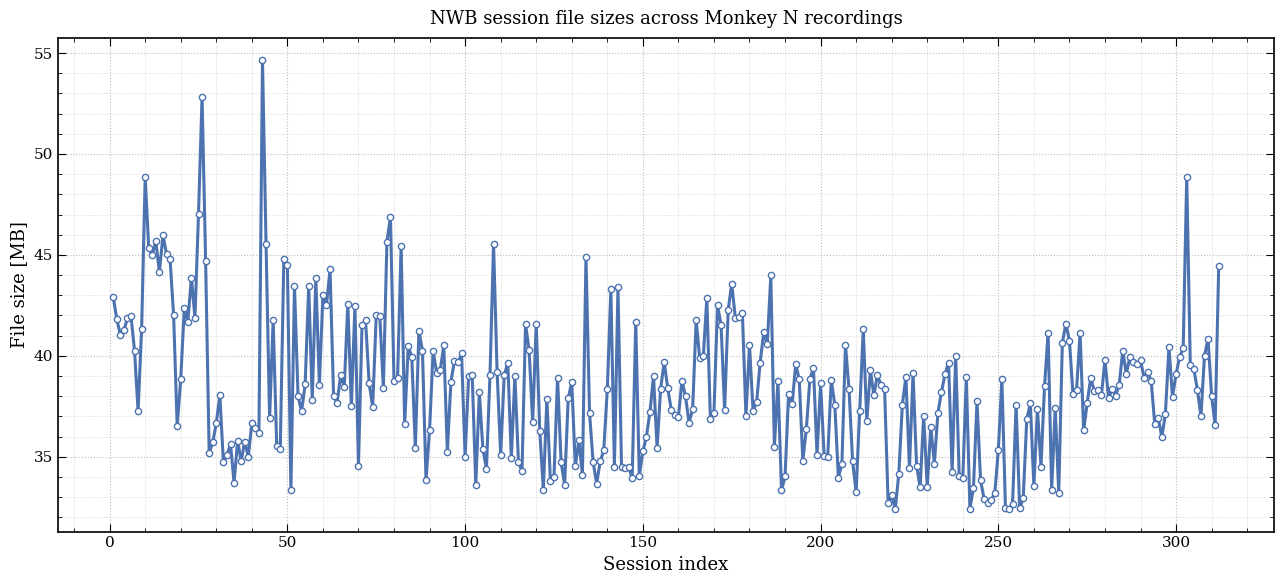

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    inventory_df["session_index"],
    inventory_df["file_size_mb"],
    color="#4C72B0",
    lw=2.2,
    marker="o",
    ms=4.5,
    markerfacecolor="white",
    markeredgewidth=1.0
)

ax.set_xlabel("Session index")
ax.set_ylabel("File size [MB]")
ax.set_title("NWB session file sizes across Monkey N recordings", pad=10)
paper_axes(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig01_session_file_sizes.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig01_session_file_sizes.pdf", dpi=300, bbox_inches="tight")
plt.show()

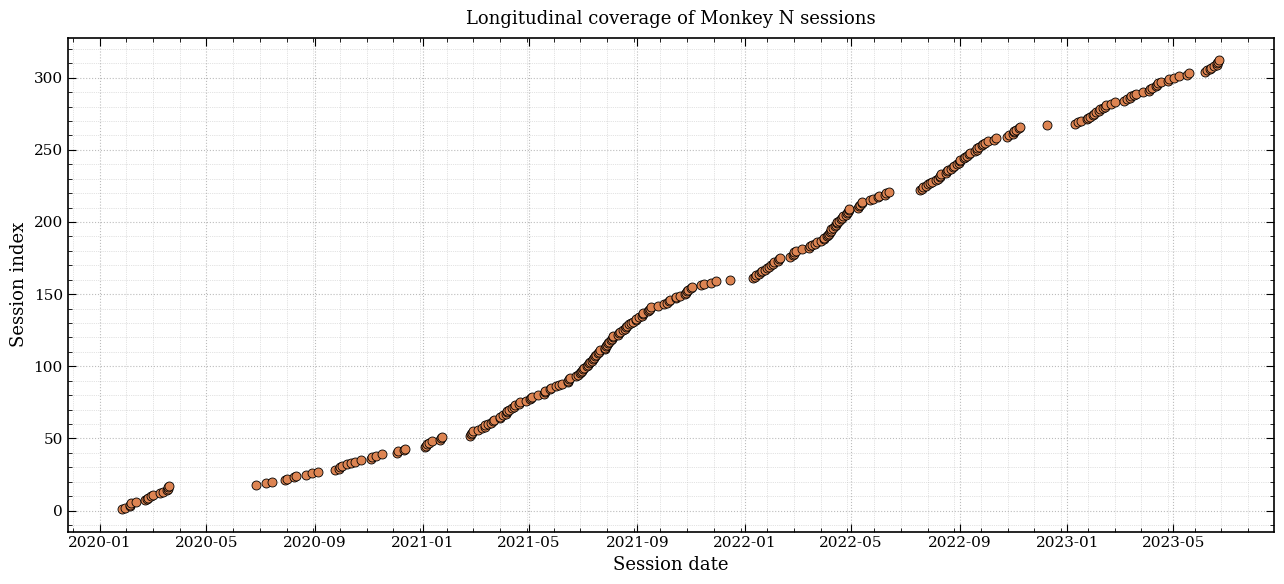

In [10]:
if inventory_df["session_date"].notna().any():
    fig, ax = plt.subplots(figsize=(13, 6))

    ax.scatter(
        inventory_df["session_date"],
        inventory_df["session_index"],
        s=42,
        color="#DD8452",
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

    ax.set_xlabel("Session date")
    ax.set_ylabel("Session index")
    ax.set_title("Longitudinal coverage of Monkey N sessions", pad=10)
    paper_axes(ax)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig02_longitudinal_coverage_dates.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / "fig02_longitudinal_coverage_dates.pdf", dpi=300, bbox_inches="tight")
    plt.show()

## Read Dandiset metadata

If `dandiset.yaml` is present, we parse it for a lightweight dataset-level summary.

In [11]:
dandiset_meta = None

if DANDISET_YAML.exists() and yaml is not None:
    with open(DANDISET_YAML, "r") as f:
        dandiset_meta = yaml.safe_load(f)

    with open(META_DIR / "dandiset_metadata.json", "w") as f:
        json.dump(dandiset_meta, f, indent=2, default=str)

    print("Top-level keys in dandiset.yaml:")
    print(list(dandiset_meta.keys())[:20])
else:
    print("dandiset.yaml not parsed (missing file or PyYAML unavailable).")

Top-level keys in dandiset.yaml:
['@context', 'about', 'access', 'assetsSummary', 'citation', 'contributor', 'dateCreated', 'datePublished', 'description', 'doi', 'ethicsApproval', 'id', 'identifier', 'keywords', 'license', 'manifestLocation', 'name', 'publishedBy', 'relatedResource', 'repository']


## NWB metadata extraction

This section scans every NWB file and extracts session-level metadata needed for manuscript preparation and later modeling notebooks.

In [12]:
def safe_len_table(tbl):
    try:
        return len(tbl)
    except Exception:
        return np.nan

def list_container_keys(container):
    try:
        return list(container.keys())
    except Exception:
        return []

def summarize_nwb_file(nwb_path):
    summary = {
        "file_name": nwb_path.name,
        "file_path": str(nwb_path),
        "session_date_from_name": extract_session_date_from_name(nwb_path),
    }

    with NWBHDF5IO(str(nwb_path), mode="r", load_namespaces=True) as io:
        nwb = io.read()

        summary["identifier"] = getattr(nwb, "identifier", None)
        summary["session_description"] = getattr(nwb, "session_description", None)
        summary["session_start_time"] = str(getattr(nwb, "session_start_time", None))
        summary["institution"] = getattr(nwb, "institution", None)
        summary["lab"] = getattr(nwb, "lab", None)
        summary["subject_id"] = getattr(getattr(nwb, "subject", None), "subject_id", None)
        summary["subject_species"] = getattr(getattr(nwb, "subject", None), "species", None)
        summary["subject_sex"] = getattr(getattr(nwb, "subject", None), "sex", None)

        summary["n_acquisition_streams"] = len(list_container_keys(nwb.acquisition))
        summary["acquisition_keys"] = list_container_keys(nwb.acquisition)

        summary["n_processing_modules"] = len(list_container_keys(nwb.processing))
        summary["processing_keys"] = list_container_keys(nwb.processing)

        summary["n_intervals_tables"] = len(list_container_keys(nwb.intervals))
        summary["intervals_keys"] = list_container_keys(nwb.intervals)

        summary["trials_present"] = nwb.trials is not None
        summary["units_present"] = nwb.units is not None
        summary["electrodes_present"] = nwb.electrodes is not None

        summary["n_trials"] = safe_len_table(nwb.trials) if nwb.trials is not None else 0
        summary["n_units"] = safe_len_table(nwb.units) if nwb.units is not None else 0
        summary["n_electrodes"] = safe_len_table(nwb.electrodes) if nwb.electrodes is not None else 0

        if nwb.trials is not None:
            try:
                summary["trial_columns"] = list(nwb.trials.colnames)
            except Exception:
                summary["trial_columns"] = []
        else:
            summary["trial_columns"] = []

        if nwb.units is not None:
            try:
                summary["unit_columns"] = list(nwb.units.colnames)
            except Exception:
                summary["unit_columns"] = []
        else:
            summary["unit_columns"] = []

        if nwb.electrodes is not None:
            try:
                summary["electrode_columns"] = list(nwb.electrodes.colnames)
            except Exception:
                summary["electrode_columns"] = []
        else:
            summary["electrode_columns"] = []

    return summary

In [13]:
session_summaries = []

for i, p in enumerate(nwb_files, start=1):
    if i % 25 == 0 or i == 1 or i == len(nwb_files):
        print(f"Processing {i}/{len(nwb_files)}: {p.name}")
    session_summaries.append(summarize_nwb_file(p))

session_df = pd.DataFrame(session_summaries)
session_df["session_date"] = pd.to_datetime(session_df["session_date_from_name"])
session_df = session_df.sort_values("session_date").reset_index(drop=True)
session_df["session_index"] = np.arange(1, len(session_df) + 1)

if session_df["session_date"].notna().any():
    first_date = session_df["session_date"].min()
    session_df["days_since_first_session"] = (session_df["session_date"] - first_date).dt.days
else:
    session_df["days_since_first_session"] = np.nan

session_df.to_csv(TAB_DIR / "nwb_session_summary.csv", index=False)
display(session_df.head(10))

Processing 1/312: sub-Monkey-N_ses-20200127_ecephys.nwb
Processing 25/312: sub-Monkey-N_ses-20200822_ecephys.nwb
Processing 50/312: sub-Monkey-N_ses-20210122_ecephys.nwb
Processing 75/312: sub-Monkey-N_ses-20210421_ecephys.nwb
Processing 100/312: sub-Monkey-N_ses-20210706_ecephys.nwb
Processing 125/312: sub-Monkey-N_ses-20210816_ecephys.nwb
Processing 150/312: sub-Monkey-N_ses-20211025_ecephys.nwb
Processing 175/312: sub-Monkey-N_ses-20220210_ecephys.nwb
Processing 200/312: sub-Monkey-N_ses-20220415_obj-y4c3g5_ecephys.nwb
Processing 225/312: sub-Monkey-N_ses-20220725_ecephys.nwb
Processing 250/312: sub-Monkey-N_ses-20220921_obj-1k78ex8_ecephys.nwb
Processing 275/312: sub-Monkey-N_ses-20230131_ecephys.nwb
Processing 300/312: sub-Monkey-N_ses-20230502_ecephys.nwb
Processing 312/312: sub-Monkey-N_ses-20230622_ecephys.nwb


,file_name,file_path,session_date_from_name,identifier,session_description,session_start_time,institution,lab,subject_id,subject_species,...,electrodes_present,n_trials,n_units,n_electrodes,trial_columns,unit_columns,electrode_columns,session_date,session_index,days_since_first_session
0,sub-Monkey-N_ses-20200127_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-27,2020-01-27_CO_nwb,Neural and behavioral data for target style CO,2020-01-27 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"[start_time, stop_time, trial_number, trial_co...",[],"[location, group, group_name, array_name, bank...",2020-01-27,1,0
1,sub-Monkey-N_ses-20200130_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-01-30,2020-01-30_CO_nwb,Neural and behavioral data for target style CO,2020-01-30 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"[start_time, stop_time, trial_number, trial_co...",[],"[location, group, group_name, array_name, bank...",2020-01-30,2,3
2,sub-Monkey-N_ses-20200204_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-04,2020-02-04_CO_nwb,Neural and behavioral data for target style CO,2020-02-04 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"[start_time, stop_time, trial_number, trial_co...",[],"[location, group, group_name, array_name, bank...",2020-02-04,3,8
3,sub-Monkey-N_ses-20200205_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-05,2020-02-05_CO_nwb,Neural and behavioral data for target style CO,2020-02-05 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"[start_time, stop_time, trial_number, trial_co...",[],"[location, group, group_name, array_name, bank...",2020-02-05,4,9
4,sub-Monkey-N_ses-20200206_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-06,2020-02-06_CO_nwb,Neural and behavioral data for target style CO,2020-02-06 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"[start_time, stop_time, trial_number, trial_co...",[],"[location, group, group_name, array_name, bank...",2020-02-06,5,10
5,sub-Monkey-N_ses-20200211_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-11,2020-02-11_CO_nwb,Neural and behavioral data for target style CO,2020-02-11 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"[start_time, stop_time, trial_number, trial_co...",[],"[location, group, group_name, array_name, bank...",2020-02-11,6,15
6,sub-Monkey-N_ses-20200222_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-22,2020-02-22_CO_nwb,Neural and behavioral data for target style CO,2020-02-22 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"[start_time, stop_time, trial_number, trial_co...",[],"[location, group, group_name, array_name, bank...",2020-02-22,7,26
7,sub-Monkey-N_ses-20200224_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-24,2020-02-24_CO_nwb,Neural and behavioral data for target style CO,2020-02-24 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"[start_time, stop_time, trial_number, trial_co...",[],"[location, group, group_name, array_name, bank...",2020-02-24,8,28
8,sub-Monkey-N_ses-20200225_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-25,2020-02-25_CO_nwb,Neural and behavioral data for target style CO,2020-02-25 00:00:00+00:00,University of Michigan,Chestek Lab,Monkey N,Macaca mulatta,...,True,375,0,96,"[start_time, stop_time, trial_number, trial_co...",[],"[location, group, group_name, array_name, bank...",2020-02-25,9,29
9,sub-Monkey-N_ses-20200228_ecephys.nwb,/kaggle/input/datasets/katakuricharlotte/dandi...,2020-02-28,2020-02-28_RD_nwb,Neural and behavioral data for target style RD,2020-02-28 00:00:00+00:

## Core metadata summary

The next cells summarize how many trials, units, electrodes, acquisition streams, and processing modules are available across sessions.

In [14]:
summary_cols = [
    "file_name", "session_date", "n_trials", "n_units", "n_electrodes",
    "n_acquisition_streams", "n_processing_modules", "n_intervals_tables",
    "trials_present", "units_present", "electrodes_present"
]
display(session_df[summary_cols].head(15))

,file_name,session_date,n_trials,n_units,n_electrodes,n_acquisition_streams,n_processing_modules,n_intervals_tables,trials_present,units_present,electrodes_present
0,sub-Monkey-N_ses-20200127_ecephys.nwb,2020-01-27,375,0,96,0,0,1,True,False,True
1,sub-Monkey-N_ses-20200130_ecephys.nwb,2020-01-30,375,0,96,0,0,1,True,False,True
2,sub-Monkey-N_ses-20200204_ecephys.nwb,2020-02-04,375,0,96,0,0,1,True,False,True
3,sub-Monkey-N_ses-20200205_ecephys.nwb,2020-02-05,375,0,96,0,0,1,True,False,True
4,sub-Monkey-N_ses-20200206_ecephys.nwb,2020-02-06,375,0,96,0,0,1,True,False,True
5,sub-Monkey-N_ses-20200211_ecephys.nwb,2020-02-11,375,0,96,0,0,1,True,False,True
6,sub-Monkey-N_ses-20200222_ecephys.nwb,2020-02-22,375,0,96,0,0,1,True,False,True
7,sub-Monkey-N_ses-20200224_ecephys.nwb,2020-02-24,375,0,96,0,0,1,True,False,True
8,sub-Monkey-N_ses-20200225_ecephys.nwb,2020-02-25,375,0,96,0,0,1,True,False,True
9,sub-Monkey-N_ses-20200228_ecephys.nwb,2020-02-28,375,0,96,0,0,1,True,False,True


In [15]:
numeric_overview = session_df[
    ["n_trials", "n_units", "n_electrodes", "n_acquisition_streams", "n_processing_modules", "n_intervals_tables"]
].describe().T

numeric_overview.to_csv(TAB_DIR / "nwb_numeric_overview.csv")
display(numeric_overview)

,count,mean,std,min,25%,50%,75%,max
n_trials,312.0,375.0,0.0,375.0,375.0,375.0,375.0,375.0
n_units,312.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
n_electrodes,312.0,96.0,0.0,96.0,96.0,96.0,96.0,96.0
n_acquisition_streams,312.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
n_processing_modules,312.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
n_intervals_tables,312.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0


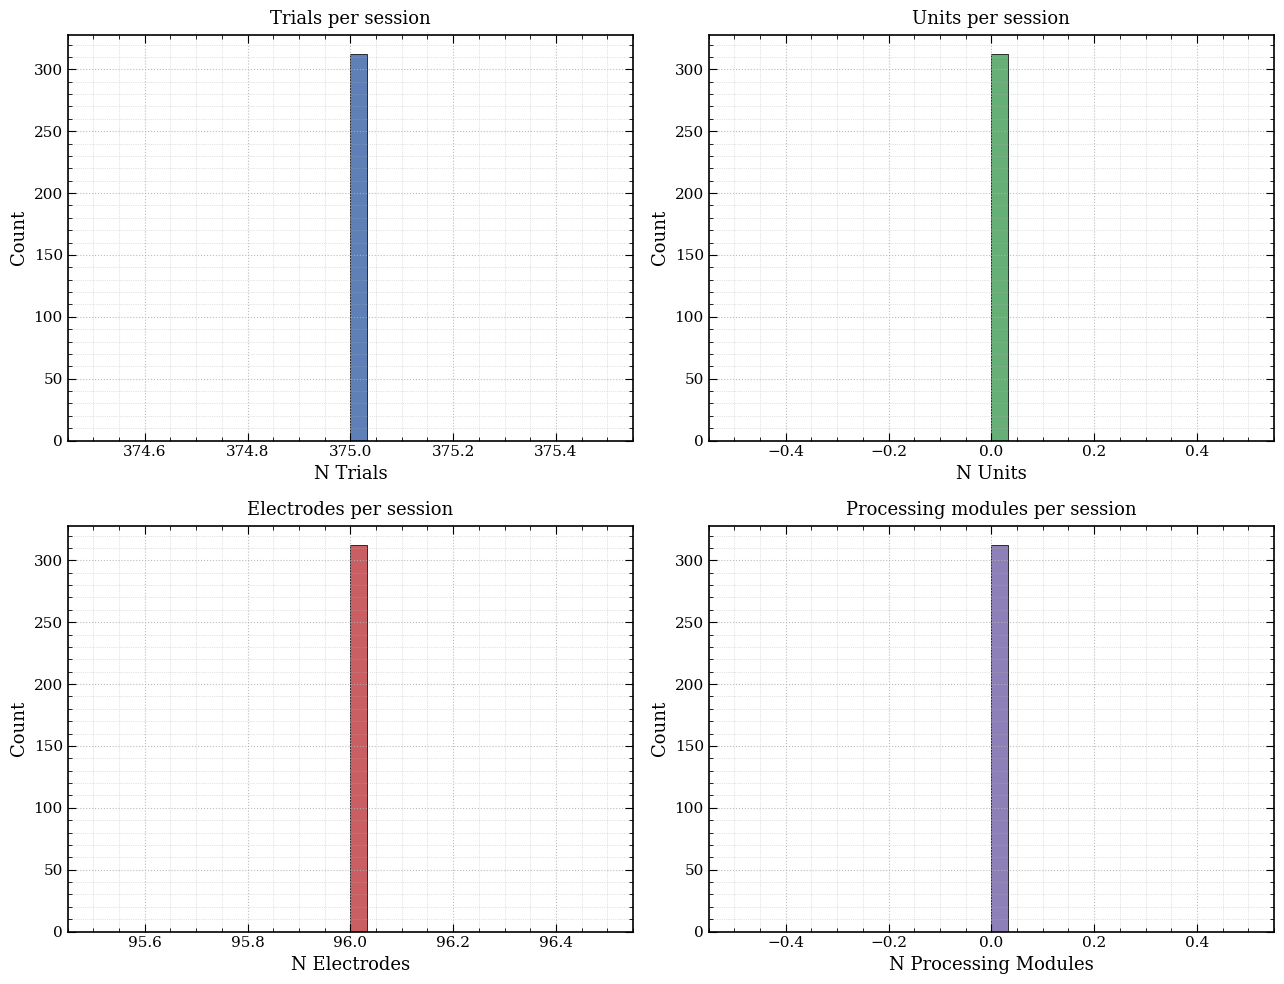

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

plots = [
    ("n_trials", "Trials per session", "#4C72B0"),
    ("n_units", "Units per session", "#55A868"),
    ("n_electrodes", "Electrodes per session", "#C44E52"),
    ("n_processing_modules", "Processing modules per session", "#8172B2"),
]

for ax, (col, title, color) in zip(axes.ravel(), plots):
    vals = session_df[col].dropna().values
    ax.hist(vals, bins=30, color=color, edgecolor="black", linewidth=0.6, alpha=0.9)
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Count")
    ax.set_title(title, pad=8)
    paper_axes(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig03_session_metadata_histograms.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig03_session_metadata_histograms.pdf", dpi=300, bbox_inches="tight")
plt.show()

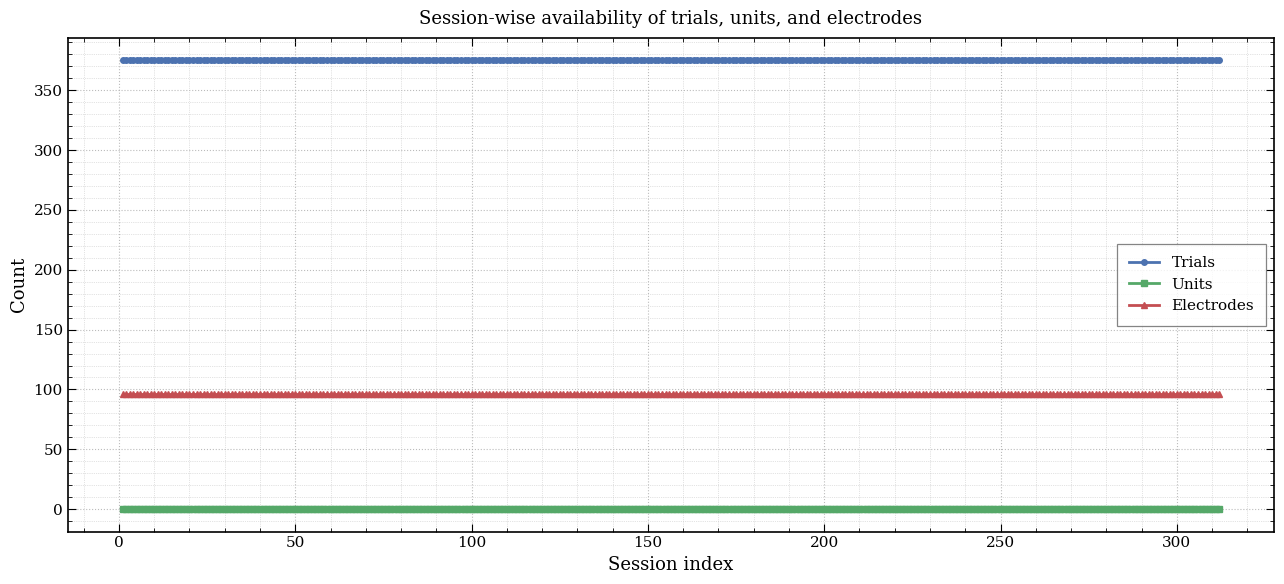

In [17]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    session_df["session_index"],
    session_df["n_trials"],
    color="#4C72B0",
    lw=2.0,
    marker="o",
    ms=4,
    label="Trials"
)

ax.plot(
    session_df["session_index"],
    session_df["n_units"],
    color="#55A868",
    lw=2.0,
    marker="s",
    ms=4,
    label="Units"
)

ax.plot(
    session_df["session_index"],
    session_df["n_electrodes"],
    color="#C44E52",
    lw=2.0,
    marker="^",
    ms=4,
    label="Electrodes"
)

ax.set_xlabel("Session index")
ax.set_ylabel("Count")
ax.set_title("Session-wise availability of trials, units, and electrodes", pad=10)
paper_axes(ax)

leg = ax.legend(loc="best", frameon=True, fancybox=False, borderpad=0.8)
leg.get_frame().set_linewidth(0.9)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig04_trials_units_electrodes_by_session.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig04_trials_units_electrodes_by_session.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Presence/absence matrix

This view is useful for quickly checking whether all sessions consistently include trials, units, and electrode tables.

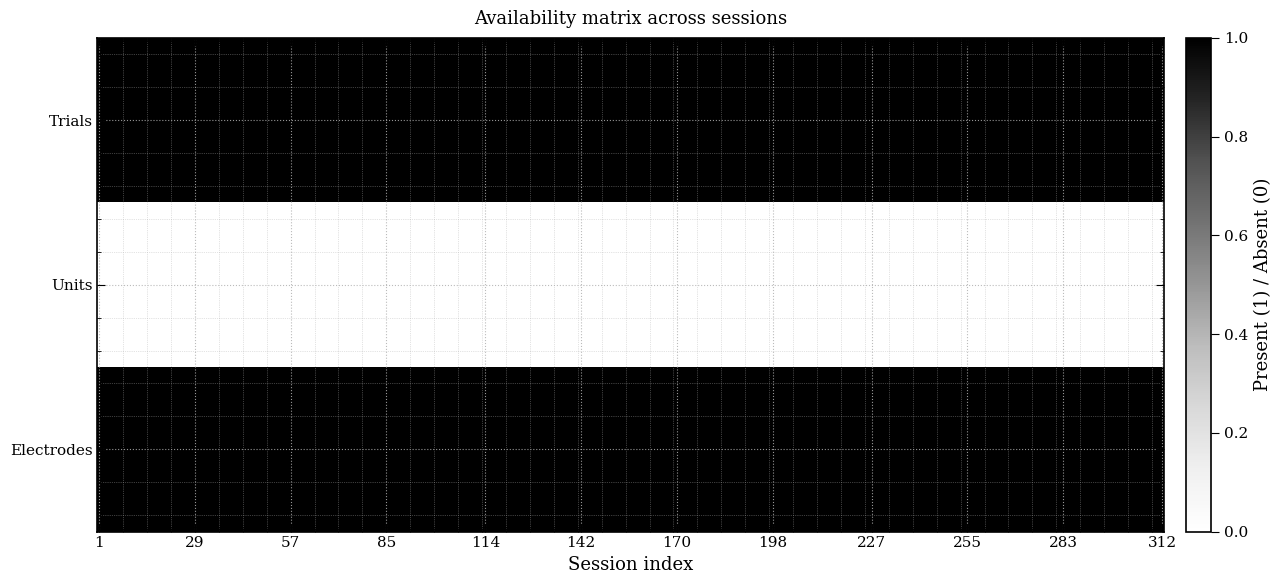

In [18]:
presence_df = session_df[["trials_present", "units_present", "electrodes_present"]].astype(int)

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(presence_df.T.values, aspect="auto", cmap="Greys", vmin=0, vmax=1)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Trials", "Units", "Electrodes"])
ax.set_xticks(np.linspace(0, len(session_df)-1, min(12, len(session_df))).astype(int))
ax.set_xticklabels((np.linspace(1, len(session_df), min(12, len(session_df))).astype(int)))
ax.set_xlabel("Session index")
ax.set_title("Availability matrix across sessions", pad=10)
paper_axes(ax)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Present (1) / Absent (0)")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig05_presence_matrix.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig05_presence_matrix.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Sample NWB deep dive

We now inspect one concrete example session:
`sub-Monkey-N_ses-20200127_ecephys.nwb`

In [19]:
with NWBHDF5IO(str(SAMPLE_NWB), mode="r", load_namespaces=True) as io:
    sample_nwb = io.read()

    sample_summary = {
        "identifier": getattr(sample_nwb, "identifier", None),
        "session_description": getattr(sample_nwb, "session_description", None),
        "session_start_time": str(getattr(sample_nwb, "session_start_time", None)),
        "subject_id": getattr(getattr(sample_nwb, "subject", None), "subject_id", None),
        "acquisition_keys": list(sample_nwb.acquisition.keys()),
        "processing_keys": list(sample_nwb.processing.keys()),
        "intervals_keys": list(sample_nwb.intervals.keys()),
        "trials_present": sample_nwb.trials is not None,
        "units_present": sample_nwb.units is not None,
        "electrodes_present": sample_nwb.electrodes is not None,
        "n_trials": len(sample_nwb.trials) if sample_nwb.trials is not None else 0,
        "n_units": len(sample_nwb.units) if sample_nwb.units is not None else 0,
        "n_electrodes": len(sample_nwb.electrodes) if sample_nwb.electrodes is not None else 0,
    }

sample_summary

{'identifier': '2020-01-27_CO_nwb',
 'session_description': 'Neural and behavioral data for target style CO',
 'session_start_time': '2020-01-27 00:00:00+00:00',
 'subject_id': 'Monkey N',
 'acquisition_keys': [],
 'processing_keys': [],
 'intervals_keys': ['trials'],
 'trials_present': True,
 'units_present': False,
 'electrodes_present': True,
 'n_trials': 375,
 'n_units': 0,
 'n_electrodes': 96}

In [20]:
with open(META_DIR / "sample_nwb_summary.json", "w") as f:
    json.dump(sample_summary, f, indent=2, default=str)

pd.Series(sample_summary)

identifier                                          2020-01-27_CO_nwb
session_description    Neural and behavioral data for target style CO
session_start_time                          2020-01-27 00:00:00+00:00
subject_id                                                   Monkey N
acquisition_keys                                                   []
processing_keys                                                    []
intervals_keys                                               [trials]
trials_present                                                   True
units_present                                                   False
electrodes_present                                               True
n_trials                                                          375
n_units                                                             0
n_electrodes                                                       96
dtype: object

In [21]:
with NWBHDF5IO(str(SAMPLE_NWB), mode="r", load_namespaces=True) as io:
    nwb = io.read()

    electrodes_df = nwb.electrodes.to_dataframe() if nwb.electrodes is not None else pd.DataFrame()
    trials_df = nwb.trials.to_dataframe() if nwb.trials is not None else pd.DataFrame()
    units_df = nwb.units.to_dataframe() if nwb.units is not None else pd.DataFrame()

print("electrodes_df shape:", electrodes_df.shape)
print("trials_df shape    :", trials_df.shape)
print("units_df shape     :", units_df.shape)

if len(electrodes_df) > 0:
    display(electrodes_df.head())

if len(trials_df) > 0:
    display(trials_df.head())

if len(units_df) > 0:
    display(units_df.head())

electrodes_df shape: (96, 10)
trials_df shape    : (375, 10)
units_df shape     : (0, 0)


,location,group,group_name,array_name,bank,pin,row,col,imp,filtering
id,,,,,,,,,,
0,Hand area of M1,Lateral pynwb.ecephys.ElectrodeGroup at 0x1342...,Lateral,Lateral,A,1,1,0,267000.0,
1,Hand area of M1,Lateral pynwb.ecephys.ElectrodeGroup at 0x1342...,Lateral,Lateral,A,2,0,0,72000.0,
2,Hand area of M1,Lateral pynwb.ecephys.ElectrodeGroup at 0x1342...,Lateral,Lateral,A,3,2,0,139000.0,
3,Hand area of M1,Lateral pynwb.ecephys.ElectrodeGroup at 0x1342...,Lateral,Lateral,A,4,3,0,232000.0,
4,Hand area of M1,Lateral pynwb.ecephys.ElectrodeGroup at 0x1342...,Lateral,Lateral,A,5,5,0,229000.0,


,start_time,stop_time,trial_number,trial_count,run_id,index_target_position,mrs_target_position,target_style,trial_timeout,timeseries
id,,,,,,,,,,
0,8.41,9.67,6,64,3,0.3,0.3,CO,30000,"[(0, 63, index_position pynwb.base.TimeSeries ..."
1,9.69,11.05,7,69,3,0.5,0.5,CO,30000,"[(64, 68, index_position pynwb.base.TimeSeries..."
2,11.07,12.95,8,95,3,0.7,0.5,CO,30000,"[(133, 94, index_position pynwb.base.TimeSerie..."
3,12.97,13.77,9,41,3,0.5,0.5,CO,30000,"[(228, 40, index_position pynwb.base.TimeSerie..."
4,13.79,17.01,10,162,3,0.2,0.8,CO,30000,"[(269, 161, index_position pynwb.base.TimeSeri..."


## Column inventory for the sample session

These column names are important because they determine what can be used later for decoding, adaptive thresholding, behavioral alignment, and longitudinal quality analysis.

In [22]:
column_inventory = {
    "electrodes_columns": list(electrodes_df.columns),
    "trials_columns": list(trials_df.columns),
    "units_columns": list(units_df.columns),
}

with open(META_DIR / "sample_column_inventory.json", "w") as f:
    json.dump(column_inventory, f, indent=2, default=str)

column_inventory

{'electrodes_columns': ['location',
  'group',
  'group_name',
  'array_name',
  'bank',
  'pin',
  'row',
  'col',
  'imp',
  'filtering'],
 'trials_columns': ['start_time',
  'stop_time',
  'trial_number',
  'trial_count',
  'run_id',
  'index_target_position',
  'mrs_target_position',
  'target_style',
  'trial_timeout',
  'timeseries'],
 'units_columns': []}

In [23]:
sample_table_summary = pd.DataFrame([
    {"table": "electrodes", "n_rows": len(electrodes_df), "n_columns": electrodes_df.shape[1]},
    {"table": "trials", "n_rows": len(trials_df), "n_columns": trials_df.shape[1]},
    {"table": "units", "n_rows": len(units_df), "n_columns": units_df.shape[1]},
])

sample_table_summary.to_csv(TAB_DIR / "sample_table_summary.csv", index=False)
display(sample_table_summary)

,table,n_rows,n_columns
0,electrodes,96,10
1,trials,375,10
2,units,0,0


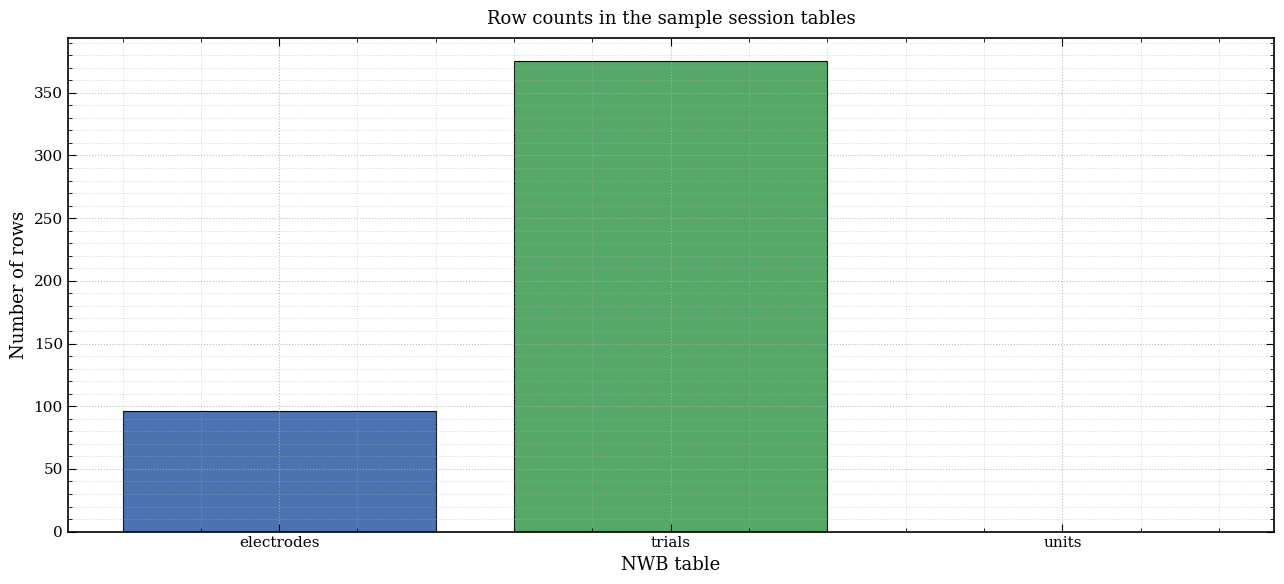

In [24]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(
    sample_table_summary["table"],
    sample_table_summary["n_rows"],
    color=["#4C72B0", "#55A868", "#C44E52"],
    edgecolor="black",
    linewidth=0.8
)

ax.set_xlabel("NWB table")
ax.set_ylabel("Number of rows")
ax.set_title("Row counts in the sample session tables", pad=10)
paper_axes(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig06_sample_table_row_counts.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig06_sample_table_row_counts.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Trial timing inspection

If trial start/stop times are available, we summarize task duration structure for the sample session.

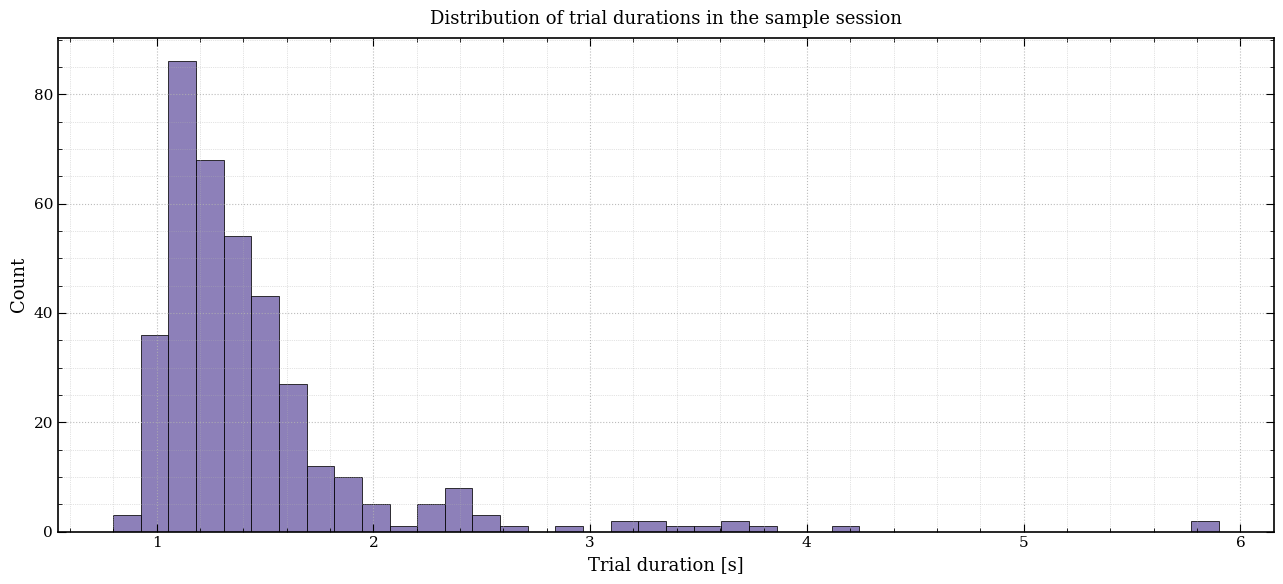

,start_time,stop_time,trial_duration
id,,,
0,8.41,9.67,1.26
1,9.69,11.05,1.36
2,11.07,12.95,1.88
3,12.97,13.77,0.80
4,13.79,17.01,3.22


In [25]:
trial_time_cols = [c for c in trials_df.columns if c.lower() in ["start_time", "stop_time"]]

if {"start_time", "stop_time"}.issubset(trials_df.columns):
    trials_df["trial_duration"] = trials_df["stop_time"] - trials_df["start_time"]

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.hist(
        trials_df["trial_duration"].dropna(),
        bins=40,
        color="#8172B2",
        edgecolor="black",
        linewidth=0.6,
        alpha=0.9
    )
    ax.set_xlabel("Trial duration [s]")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of trial durations in the sample session", pad=10)
    paper_axes(ax)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig07_trial_duration_distribution.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / "fig07_trial_duration_distribution.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    display(trials_df[["start_time", "stop_time", "trial_duration"]].head())
else:
    print("start_time/stop_time columns not both present in trials_df.")

## Electrode metadata inspection

This section helps us understand the recording array annotation available per session.

In [26]:
if len(electrodes_df) > 0:
    electrode_profile = pd.DataFrame({
        "column": electrodes_df.columns,
        "dtype": electrodes_df.dtypes.astype(str).values,
        "n_missing": electrodes_df.isna().sum().values,
        "pct_missing": (100 * electrodes_df.isna().mean()).round(2).values,
        "n_unique": [electrodes_df[c].nunique(dropna=True) for c in electrodes_df.columns],
    }).sort_values(["pct_missing", "n_unique"], ascending=[False, False])

    electrode_profile.to_csv(TAB_DIR / "electrode_profile_sample.csv", index=False)
    display(electrode_profile.head(25))
else:
    print("No electrodes table available.")

,column,dtype,n_missing,pct_missing,n_unique
8,imp,float64,0,0.0,92
5,pin,int64,0,0.0,32
6,row,int64,0,0.0,8
7,col,int64,0,0.0,8
4,bank,object,0,0.0,3
1,group,object,0,0.0,2
2,group_name,object,0,0.0,2
3,array_name,object,0,0.0,2
0,location,object,0,0.0,1
9,filtering,object,0,0.0,1


In [ ]:
if len(electrodes_df) > 0:
    numeric_electrode_cols = [c for c in electrodes_df.columns if pd.api.types.is_numeric_dtype(electrodes_df[c])]
    numeric_electrode_cols = numeric_electrode_cols[:6]

    if len(numeric_electrode_cols) > 0:
        fig, axes = plt.subplots(len(numeric_electrode_cols), 1, figsize=(13, 3 * len(numeric_electrode_cols)))
        if len(numeric_electrode_cols) == 1:
            axes = [axes]

        for ax, col in zip(axes, numeric_electrode_cols):
            ax.hist(
                electrodes_df[col].dropna(),
                bins=40,
                color="#64B5CD",
                edgecolor="black",
                linewidth=0.5,
                alpha=0.9
            )
            ax.set_xlabel(col)
            ax.set_ylabel("Count")
            ax.set_title(f"Electrode distribution: {col}", pad=8)
            paper_axes(ax)

        plt.tight_layout()
        plt.savefig(FIG_DIR / "fig08_electrode_numeric_distributions.png", dpi=300, bbox_inches="tight")
        plt.savefig(FIG_DIR / "fig08_electrode_numeric_distributions.pdf", dpi=300, bbox_inches="tight")
        plt.show()
    else:
        print("No numeric electrode columns found.")
else:
    print("No electrodes table available.")

## Unit metadata inspection

The unit table often contains important information for spike-based analyses, waveform quality, and decoding inputs.

In [ ]:
if len(units_df) > 0:
    unit_profile = pd.DataFrame({
        "column": units_df.columns,
        "dtype": units_df.dtypes.astype(str).values,
        "n_missing": units_df.isna().sum().values,
        "pct_missing": (100 * units_df.isna().mean()).round(2).values,
        "n_unique": [units_df[c].nunique(dropna=True) for c in units_df.columns],
    }).sort_values(["pct_missing", "n_unique"], ascending=[False, False])

    unit_profile.to_csv(TAB_DIR / "unit_profile_sample.csv", index=False)
    display(unit_profile.head(25))
else:
    print("No units table available.")

In [ ]:
if len(units_df) > 0:
    numeric_unit_cols = [c for c in units_df.columns if pd.api.types.is_numeric_dtype(units_df[c])]
    numeric_unit_cols = numeric_unit_cols[:6]

    if len(numeric_unit_cols) > 0:
        fig, axes = plt.subplots(len(numeric_unit_cols), 1, figsize=(13, 3 * len(numeric_unit_cols)))
        if len(numeric_unit_cols) == 1:
            axes = [axes]

        for ax, col in zip(axes, numeric_unit_cols):
            ax.hist(
                units_df[col].dropna(),
                bins=40,
                color="#DD8452",
                edgecolor="black",
                linewidth=0.5,
                alpha=0.9
            )
            ax.set_xlabel(col)
            ax.set_ylabel("Count")
            ax.set_title(f"Unit distribution: {col}", pad=8)
            paper_axes(ax)

        plt.tight_layout()
        plt.savefig(FIG_DIR / "fig09_unit_numeric_distributions.png", dpi=300, bbox_inches="tight")
        plt.savefig(FIG_DIR / "fig09_unit_numeric_distributions.pdf", dpi=300, bbox_inches="tight")
        plt.show()
    else:
        print("No numeric unit columns found.")
else:
    print("No units table available.")

## Session-level column consistency

For later notebooks, it is useful to know whether the trial, unit, and electrode schemas are stable across sessions.

In [ ]:
def normalize_col_list(x):
    if isinstance(x, list):
        return tuple(x)
    return tuple([])

schema_consistency_df = pd.DataFrame({
    "file_name": session_df["file_name"],
    "trial_columns_signature": session_df["trial_columns"].apply(normalize_col_list),
    "unit_columns_signature": session_df["unit_columns"].apply(normalize_col_list),
    "electrode_columns_signature": session_df["electrode_columns"].apply(normalize_col_list),
})

trial_schema_counts = schema_consistency_df["trial_columns_signature"].value_counts().rename("count").reset_index()
unit_schema_counts = schema_consistency_df["unit_columns_signature"].value_counts().rename("count").reset_index()
electrode_schema_counts = schema_consistency_df["electrode_columns_signature"].value_counts().rename("count").reset_index()

trial_schema_counts.to_csv(TAB_DIR / "trial_schema_signatures.csv", index=False)
unit_schema_counts.to_csv(TAB_DIR / "unit_schema_signatures.csv", index=False)
electrode_schema_counts.to_csv(TAB_DIR / "electrode_schema_signatures.csv", index=False)

print("Unique trial schemas:", len(trial_schema_counts))
print("Unique unit schemas:", len(unit_schema_counts))
print("Unique electrode schemas:", len(electrode_schema_counts))

In [ ]:
schema_bar_df = pd.DataFrame({
    "table": ["Trials", "Units", "Electrodes"],
    "n_unique_schemas": [len(trial_schema_counts), len(unit_schema_counts), len(electrode_schema_counts)]
})

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(
    schema_bar_df["table"],
    schema_bar_df["n_unique_schemas"],
    color=["#4C72B0", "#55A868", "#C44E52"],
    edgecolor="black",
    linewidth=0.8
)

ax.set_xlabel("NWB table")
ax.set_ylabel("Number of unique schema signatures")
ax.set_title("Schema stability across sessions", pad=10)
paper_axes(ax)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig10_schema_stability.png", dpi=300, bbox_inches="tight")
plt.savefig(FIG_DIR / "fig10_schema_stability.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Longitudinal gaps between sessions

This helps characterize the temporal spacing of recordings and is useful when planning chronic stability analyses.

In [ ]:
if session_df["session_date"].notna().sum() >= 2:
    temp_df = session_df[["session_date"]].dropna().sort_values("session_date").copy()
    temp_df["gap_days"] = temp_df["session_date"].diff().dt.days

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.hist(
        temp_df["gap_days"].dropna(),
        bins=30,
        color="#937860",
        edgecolor="black",
        linewidth=0.6,
        alpha=0.9
    )
    ax.set_xlabel("Gap between consecutive sessions [days]")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of inter-session gaps", pad=10)
    paper_axes(ax)

    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig11_intersession_gap_distribution.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / "fig11_intersession_gap_distribution.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    temp_df.to_csv(TAB_DIR / "intersession_gaps.csv", index=False)
    display(temp_df.head(10))

## Compact EDA report

This final section writes a concise machine-readable and human-readable EDA summary for reuse in later notebooks.

In [ ]:
eda_summary = {
    "dataset_dir": str(DATASET_DIR),
    "sample_nwb": str(SAMPLE_NWB),
    "n_nwb_files": int(len(nwb_files)),
    "date_min": str(session_df["session_date"].min()) if session_df["session_date"].notna().any() else None,
    "date_max": str(session_df["session_date"].max()) if session_df["session_date"].notna().any() else None,
    "mean_file_size_mb": float(inventory_df["file_size_mb"].mean()),
    "median_n_trials": float(session_df["n_trials"].median()),
    "median_n_units": float(session_df["n_units"].median()),
    "median_n_electrodes": float(session_df["n_electrodes"].median()),
    "all_sessions_have_trials_table": bool(session_df["trials_present"].all()),
    "all_sessions_have_units_table": bool(session_df["units_present"].all()),
    "all_sessions_have_electrodes_table": bool(session_df["electrodes_present"].all()),
}

with open(META_DIR / "eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=2, default=str)

report_lines = [
    "EDA SUMMARY",
    f"Dataset directory: {eda_summary['dataset_dir']}",
    f"Sample NWB file: {eda_summary['sample_nwb']}",
    f"Number of NWB files: {eda_summary['n_nwb_files']}",
    f"Date range: {eda_summary['date_min']} to {eda_summary['date_max']}",
    f"Mean file size [MB]: {eda_summary['mean_file_size_mb']:.2f}",
    f"Median trials/session: {eda_summary['median_n_trials']:.2f}",
    f"Median units/session: {eda_summary['median_n_units']:.2f}",
    f"Median electrodes/session: {eda_summary['median_n_electrodes']:.2f}",
    f"All sessions have trials table: {eda_summary['all_sessions_have_trials_table']}",
    f"All sessions have units table: {eda_summary['all_sessions_have_units_table']}",
    f"All sessions have electrodes table: {eda_summary['all_sessions_have_electrodes_table']}",
]

report_text = "\n".join(report_lines)

with open(META_DIR / "eda_report.txt", "w") as f:
    f.write(report_text)

print(report_text)

In [ ]:
generated_figs = sorted([p.name for p in FIG_DIR.glob("*")])
generated_tabs = sorted([p.name for p in TAB_DIR.glob("*")])
generated_meta = sorted([p.name for p in META_DIR.glob("*")])

print("Generated figures:")
for x in generated_figs:
    print(" -", x)

print("\nGenerated tables:")
for x in generated_tabs:
    print(" -", x)

print("\nGenerated metadata files:")
for x in generated_meta:
    print(" -", x)